In [1]:
!pip install ydata-profiling
import pandas as pd
from ydata_profiling import ProfileReport

from google.colab import files
uploaded = files.upload()


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=2bc27d46892ab9be4b42df235c0347c9e64877e0cac479e2d3cbeb84e2768e6f
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin


Saving Tuberculosis_Trends.csv to Tuberculosis_Trends.csv


In [29]:
pip install nbstripout


In [2]:
import pandas as pd
df = pd.read_csv('Tuberculosis_Trends.csv')


In [3]:
#EDA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df.head()


,Country,Region,Income_Level,Year,TB_Cases,TB_Deaths,TB_Incidence_Rate,TB_Mortality_Rate,TB_Treatment_Success_Rate,Drug_Resistant_TB_Cases,...,GDP_Per_Capita,Health_Expenditure_Per_Capita,Urban_Population_Percentage,Malnutrition_Prevalence,Smoking_Prevalence,TB_Doctors_Per_100K,TB_Hospitals_Per_Million,Access_To_Health_Services,BCG_Vaccination_Coverage,HIV_Testing_Coverage
0,Indonesia,Asia,Upper-Middle,2002,14128,3846,150.58,18.99,54.52,3977,...,25516,3180,50.49,28.84,22.90,4.10,15.46,52.38,95.87,88.39
1,Brazil,North America,Lower-Middle,2017,1069,342,167.80,44.20,88.19,4179,...,26300,5529,24.06,28.65,33.79,8.18,3.06,46.95,63.78,35.60
2,Nigeria,South America,High,2006,2473,6316,285.77,6.52,64.55,4961,...,30771,1703,81.77,38.69,6.63,2.26,4.95,40.88,68.91,77.81
3,Russia,Africa,Lower-Middle,2014,36090,6420,146.46,24.86,69.77,4012,...,35730,8354,42.19,20.38,15.00,8.33,13.68,62.20,71.14,84.91
4,Indonesia,Europe,Upper-Middle,2020,33538,4910,56.87,10.52,64.57,2342,...,38391,8024,64.97,39.28,18.00,6.60,4.35,53.88,55.11,49.89


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        3000 non-null   object 
 1   Region                         3000 non-null   object 
 2   Income_Level                   3000 non-null   object 
 3   Year                           3000 non-null   int64  
 4   TB_Cases                       3000 non-null   int64  
 5   TB_Deaths                      3000 non-null   int64  
 6   TB_Incidence_Rate              3000 non-null   float64
 7   TB_Mortality_Rate              3000 non-null   float64
 8   TB_Treatment_Success_Rate      3000 non-null   float64
 9   Drug_Resistant_TB_Cases        3000 non-null   int64  
 10  HIV_CoInfected_TB_Cases        3000 non-null   int64  
 11  Population                     3000 non-null   int64  
 12  GDP_Per_Capita                 3000 non-null   i

In [5]:
df.describe()

,Year,TB_Cases,TB_Deaths,TB_Incidence_Rate,TB_Mortality_Rate,TB_Treatment_Success_Rate,Drug_Resistant_TB_Cases,HIV_CoInfected_TB_Cases,Population,GDP_Per_Capita,Health_Expenditure_Per_Capita,Urban_Population_Percentage,Malnutrition_Prevalence,Smoking_Prevalence,TB_Doctors_Per_100K,TB_Hospitals_Per_Million,Access_To_Health_Services,BCG_Vaccination_Coverage,HIV_Testing_Coverage
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2012.049000,24807.937667,5090.818333,255.845483,25.119210,72.484597,2501.796333,4929.499333,7.036535e+08,30046.892333,5039.485667,54.558710,27.549927,22.439453,5.015230,10.268077,64.597103,74.588197,55.498690
std,7.247306,14261.279606,2846.753032,140.651939,14.031132,13.112578,1440.032384,2846.943009,4.018102e+08,17172.813451,2870.269590,20.124572,12.974430,10.179438,2.851124,5.717438,19.990994,14.124815,20.250306
min,2000.000000,515.000000,50.000000,10.060000,1.010000,50.000000,13.000000,10.000000,1.088106e+06,501.000000,50.000000,20.000000,5.010000,5.020000,0.100000,0.510000,30.010000,50.020000,20.000000
25%,2006.000000,12297.750000,2660.500000,133.662500,12.962500,61.067500,1236.000000,2520.750000,3.636371e+08,15212.000000,2543.500000,37.067500,16.385000,13.750000,2.520000,5.130000,47.240000,62.517500,38.240000
50%,2012.000000,24467.000000,5188.000000,255.770000,25.090000,72.545000,2525.500000,4864.000000,6.970638e+08,29707.000000,5008.000000,54.775000,27.635000,22.195000,4.930000,10.390000,64.630000,74.870000,55.825000
75%,2018.000000,37031.500000,7512.500000,374.647500,36.900000,84.025000,3740.000000,7328.500000,1.041607e+09,44463.000000,7518.750000,71.575000,38.782500,31.522500,7.480000,15.360000,81.342500,86.645000,73.497500
max,2024.000000,49985.000000,9991.000000,499.950000,49.990000,94.980000,4999.000000,9989.000000,1.399285e+09,59996.000000,9999.000000,89.990000,49.970000,40.000000,10.000000,20.000000,99.960000,98.990000,89.980000


In [6]:
#data cleaning, check if any duplicates and remove if needed
duplicates = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicates}")

Number of duplicated rows: 0


In [7]:
# data cleaning, check if any missing values
missing_values = df.isnull().sum()
print(missing_values)

Country                          0
Region                           0
Income_Level                     0
Year                             0
TB_Cases                         0
TB_Deaths                        0
TB_Incidence_Rate                0
TB_Mortality_Rate                0
TB_Treatment_Success_Rate        0
Drug_Resistant_TB_Cases          0
HIV_CoInfected_TB_Cases          0
Population                       0
GDP_Per_Capita                   0
Health_Expenditure_Per_Capita    0
Urban_Population_Percentage      0
Malnutrition_Prevalence          0
Smoking_Prevalence               0
TB_Doctors_Per_100K              0
TB_Hospitals_Per_Million         0
Access_To_Health_Services        0
BCG_Vaccination_Coverage         0
HIV_Testing_Coverage             0
dtype: int64


In [8]:
#data cleaning, standardize categorical values and check consistency
categorical_cols = ['Country', 'Region', 'Income_Level']
for col in categorical_cols:
    df[col] = df[col].str.strip().str.title()

print(df['Country'].unique())
print(df['Region'].unique())
print(df['Income_Level'].unique())

['Indonesia' 'Brazil' 'Nigeria' 'Russia' 'Bangladesh' 'Usa' 'South Africa'
 'China' 'India' 'Pakistan']
['Asia' 'North America' 'South America' 'Africa' 'Europe']
['Upper-Middle' 'Lower-Middle' 'High' 'Low']


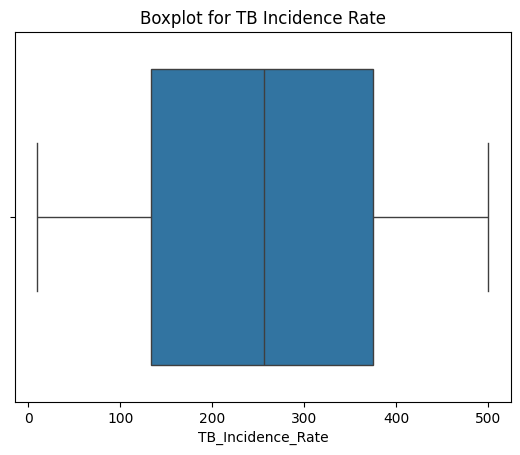

Outlier count by column:
Year                             0
TB_Cases                         0
TB_Deaths                        0
TB_Incidence_Rate                0
TB_Mortality_Rate                0
TB_Treatment_Success_Rate        0
Drug_Resistant_TB_Cases          0
HIV_CoInfected_TB_Cases          0
Population                       0
GDP_Per_Capita                   0
Health_Expenditure_Per_Capita    0
Urban_Population_Percentage      0
Malnutrition_Prevalence          0
Smoking_Prevalence               0
TB_Doctors_Per_100K              0
TB_Hospitals_Per_Million         0
Access_To_Health_Services        0
BCG_Vaccination_Coverage         0
HIV_Testing_Coverage             0
dtype: int64


In [9]:
#data cleaning, check for outliers using visual method boxplot
sns.boxplot(x=df['TB_Incidence_Rate'])
plt.title("Boxplot for TB Incidence Rate")
plt.show()

#check outlier across all columns by IQR method
import numpy as np
def outliers_summary(df):
    outlier_counts = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_counts[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    return pd.Series(outlier_counts).sort_values(ascending=False)

print("Outlier count by column:")
print(outliers_summary(df))

In [10]:
#check frequency consistency across categories
pd.crosstab(df['Income_Level'], df['Region'], values=df['TB_Cases'], aggfunc='sum')

Region,Africa,Asia,Europe,North America,South America
Income_Level,,,,,
High,3638703,3614830,3959152,3406009,3411401
Low,4224731,3318082,3163091,3699927,4173402
Lower-Middle,4058212,4172061,3667780,4113822,3968071
Upper-Middle,3807617,3791209,3330098,3835214,3070401


In [11]:
profile = ProfileReport(df, title="Tuberculosis EDA Report", explorative=True)
profile.to_file("tb_eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 22/22 [00:00<00:00, 65.38it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
files.download('tb_eda_report.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

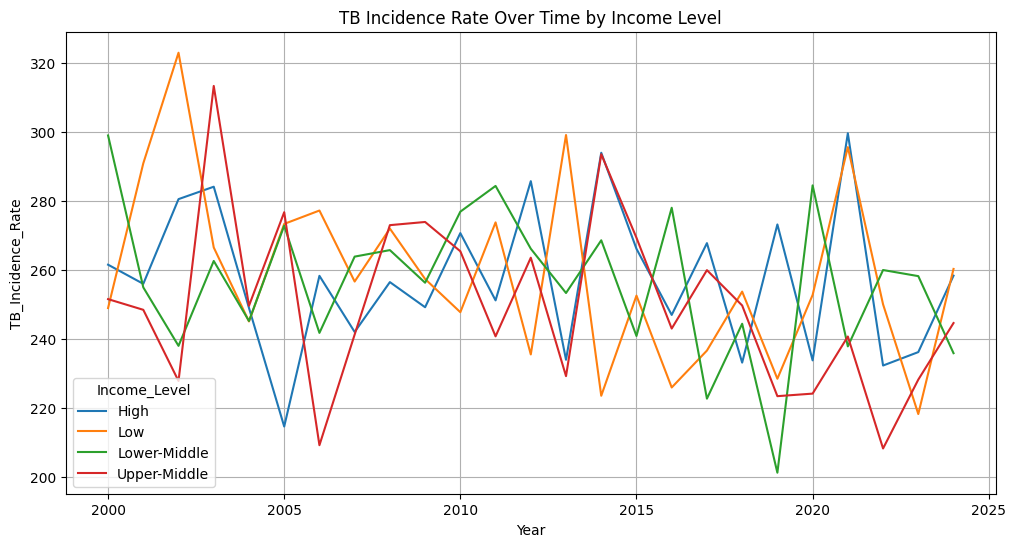

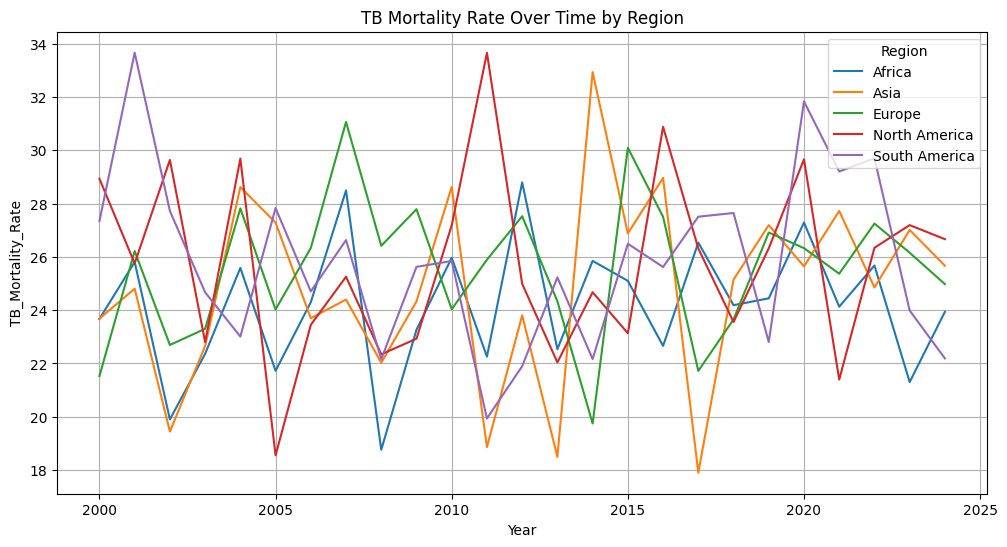

In [13]:
#to answer RQ1: How have TB incidence and mortality rates evolved over time across different income levels and world regions?

#Group by Year and Income_Level, then take the mean
grouped_income = df.groupby(['Year', 'Income_Level'])[['TB_Incidence_Rate', 'TB_Mortality_Rate']].mean().reset_index()

#Group by Year and Region
grouped_region = df.groupby(['Year', 'Region'])[['TB_Incidence_Rate', 'TB_Mortality_Rate']].mean().reset_index()

#TB Incidence over time by Income_Level
plt.figure(figsize=(12,6))
sns.lineplot(data=grouped_income, x='Year', y='TB_Incidence_Rate', hue='Income_Level')
plt.title("TB Incidence Rate Over Time by Income Level")
plt.grid(True)
plt.show()

#TB Mortality over time by Region
plt.figure(figsize=(12,6))
sns.lineplot(data=grouped_region, x='Year', y='TB_Mortality_Rate', hue='Region')
plt.title("TB Mortality Rate Over Time by Region")
plt.grid(True)
plt.show()

In [14]:
import statsmodels.formula.api as smf
# Fit model: Incidence ~ Year + Income_Level (categorical)
model_inc = smf.ols('TB_Incidence_Rate ~ Year * C(Income_Level)', data=df).fit()
print(model_inc.summary())

# Fit model: Mortality ~ Year + Region (categorical)
model_mort = smf.ols('TB_Mortality_Rate ~ Year * C(Region)', data=df).fit()
print(model_mort.summary())

                            OLS Regression Results                            
Dep. Variable:      TB_Incidence_Rate   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.257
Date:                Sat, 12 Jul 2025   Prob (F-statistic):              0.268
Time:                        16:53:10   Log-Likelihood:                -19091.
No. Observations:                3000   AIC:                         3.820e+04
Df Residuals:                    2992   BIC:                         3.825e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


TB rate vs year&income level:
*   R-square is 0.003 which is very weak
*   p-value is 0.268, the overall model is not statistically significant.

TB rate vs year&region:
*   R-square: 0.003, also very weak
*   p-value:0.53 also means the overall model is not statistically significant.


In general, extremently low R-square values meaning predictors (year, region/income) explains almost none of the variation. There is no evidence of meaningful change over time.


In [28]:
import statsmodels.api as sm

# ANOVA to compare models with/without interaction
anova_inc = sm.stats.anova_lm(model_inc, typ=2)
anova_mort = sm.stats.anova_lm(model_mort, typ=2)

print("ANOVA for Incidence by Income Level")
print(anova_inc)

print("ANOVA for Mortality by Region")
print(anova_mort)

ANOVA for Incidence by Income Level
                            sum_sq      df         F    PR(>F)
C(Income_Level)       3.093985e+04     3.0  0.521634  0.667408
Year                  1.167936e+05     1.0  5.907287  0.015137
Year:C(Income_Level)  2.502735e+04     3.0  0.421952  0.737270
Residual              5.915515e+07  2992.0       NaN       NaN
ANOVA for Mortality by Region
                       sum_sq      df         F    PR(>F)
C(Region)         1065.534085     4.0  1.352643  0.247982
Year               290.096496     1.0  1.473053  0.224960
Year:C(Region)     252.301924     4.0  0.320285  0.864541
Residual        588837.291718  2990.0       NaN       NaN


There is a significant overall time trend in TB incidence (p = 0.015 which p<0.05), but income level alone, or its interaction with time, is not significant. TB incidence has changed over time, but not differently across income levels. As for region, neither region, year, nor their interaction significantly affects TB mortality

In [16]:
#to answer RQ2: 2.	Which socioeconomic, health, and demographic factors are the most important predictors of TB incidence rate across countries and years?"
predictors = [
    'GDP_Per_Capita',
    'Health_Expenditure_Per_Capita',
    'Urban_Population_Percentage',
    'Malnutrition_Prevalence',
    'Smoking_Prevalence',
    'Access_To_Health_Services',
    'HIV_CoInfected_TB_Cases',
    'BCG_Vaccination_Coverage',
    'HIV_Testing_Coverage',
    'Population'
]

target = 'TB_Incidence_Rate'

from sklearn.preprocessing import StandardScaler

# Scale predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[predictors])
X = pd.DataFrame(X_scaled, columns=predictors)
y = df[target]


Reason for choosing specific predictors:


*   GDP per capita: this represents the economic development, countries with lower income often have weaker health infrastructure and higher TB incidence.
*   Health expenditure per capita: measures the national investment in healthcare, higher spending may better prevent and treat TB.
*   Urban population percentage: crowded condition can spread more TB cases.
*   Malnutrition prevalence: this weakens the immune system, which may increases the TB spread and mortality rate.
*   Smoking prevalence: this damages the lungs, make people more vulnerable for the desease.
*   Access to health services: shows health system accessibility to TB detection, diagnosis and treatment.
*   HIV Coinfected TB cases: HIV may significantly increases TB risk.
*   BCG vaccination coverage: it is tied with TB prevention and may reduce the TB cases.
*   HIV testing coverage: reflects awaareness and early intervention in HIV related TB risks.
*   Population: more population increases the risk to spread TB cases.




In [17]:
#train model
# Add constant for intercept
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      TB_Incidence_Rate   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6860
Date:                Sat, 12 Jul 2025   Prob (F-statistic):              0.738
Time:                        16:53:21   Log-Likelihood:                -19092.
No. Observations:                3000   AIC:                         3.821e+04
Df Residuals:                    2989   BIC:                         3.827e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

*   R-square:0.002 means model explains only 0.2% of the variation in TB incidence, which is very weak predictive power.
*   F-stat:0.686, not siginicant.
*   p-value: 0.738 not statistically significant.


In [18]:
#Get absolute values of coefficients (excluding intercept)
importance = model.params.drop('const').abs().sort_values(ascending=False)
print("Feature importance (based on coefficient magnitude):")
print(importance)

Feature importance (based on coefficient magnitude):
Smoking_Prevalence               4.652038
Malnutrition_Prevalence          2.862720
Population                       2.674140
Urban_Population_Percentage      1.806307
HIV_CoInfected_TB_Cases          1.751852
Health_Expenditure_Per_Capita    1.272747
BCG_Vaccination_Coverage         0.937355
GDP_Per_Capita                   0.510700
HIV_Testing_Coverage             0.308932
Access_To_Health_Services        0.035148
dtype: float64


Stronger predictor on the top and less strong predictor on the bottom. The strongest predictors of TB incidence are lifestyle-related health vulnerabilities (smoking, malnutrition), demographic pressure (population, urbanization), and co-infections (HIV). Traditional economic indicators like GDP and healthcare spending, while relevant, show less direct predictive power in this context.

In [19]:
#to answer RQ3:3.	Do countries with higher BCG vaccination coverage have lower TB mortality rates, after controlling for health and socioeconomic factors?

# Dependent variable
target = 'TB_Mortality_Rate'

# Independent variables including BCG vaccination and control variables
predictors = [
    'BCG_Vaccination_Coverage',
    'GDP_Per_Capita',
    'Health_Expenditure_Per_Capita',
    'Access_To_Health_Services',
    'HIV_CoInfected_TB_Cases',
    'Smoking_Prevalence',
    'Urban_Population_Percentage'
]

In [20]:
#feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[predictors])
X = pd.DataFrame(X_scaled, columns=predictors)
y = df[target]

In [21]:
#fit the full model with BCG vaccination
X_with_bcg = sm.add_constant(X)
model_with_bcg = sm.OLS(y, X_with_bcg).fit()
print("Full Model (with BCG):")
print(model_with_bcg.summary())

Full Model (with BCG):
                            OLS Regression Results                            
Dep. Variable:      TB_Mortality_Rate   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6544
Date:                Sat, 12 Jul 2025   Prob (F-statistic):              0.711
Time:                        16:59:54   Log-Likelihood:                -12178.
No. Observations:                3000   AIC:                         2.437e+04
Df Residuals:                    2992   BIC:                         2.442e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [22]:
#fit the reduced model by removing BCG vaccination
X_reduced = X.drop(columns=['BCG_Vaccination_Coverage'])
X_reduced = sm.add_constant(X_reduced)
model_without_bcg = sm.OLS(y, X_reduced).fit()
print("\nReduced Model (without BCG):")
print(model_without_bcg.summary())


Reduced Model (without BCG):
                            OLS Regression Results                            
Dep. Variable:      TB_Mortality_Rate   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7092
Date:                Sat, 12 Jul 2025   Prob (F-statistic):              0.642
Time:                        17:00:13   Log-Likelihood:                -12178.
No. Observations:                3000   AIC:                         2.437e+04
Df Residuals:                    2993   BIC:                         2.441e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

All P-value are greater than 0.05, meaning none of the variables are significant predictor of TB mortality rate in this dataset.

In [26]:
#evaluate and compare models
print("\nModel Comparison:")
print(f"R² (with BCG): {model_with_bcg.rsquared:.4f}")
print(f"R² (without BCG): {model_without_bcg.rsquared:.4f}")



Model Comparison:
R² (with BCG): 0.0015
R² (without BCG): 0.0014


R-square with BCG only improves variance by 0.01%, which is negligble and not significant. This means that BCG vaccination coverage is not a significant or useful predictor of TB mortality rate in this dataset, after adjusting for other factors.

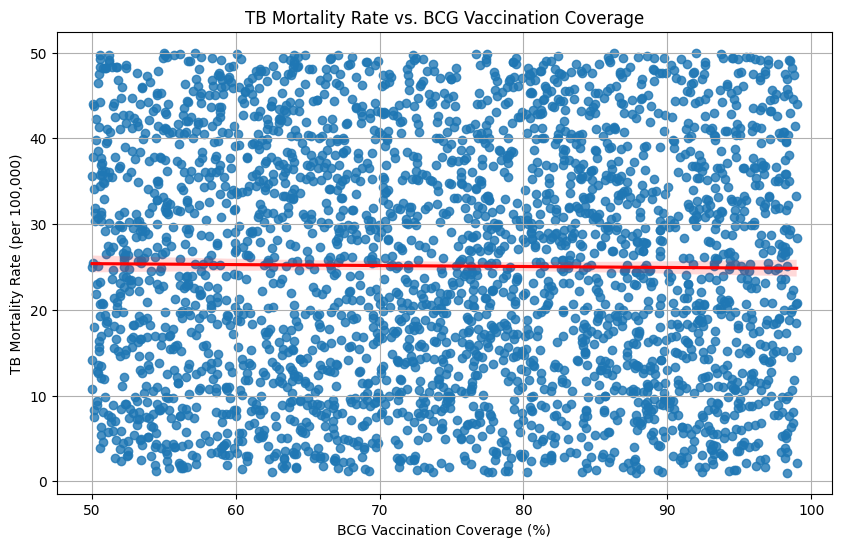

In [24]:
# visualization with scatterplot
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x='BCG_Vaccination_Coverage',
    y='TB_Mortality_Rate',
    line_kws={'color': 'red'}
)
plt.title("TB Mortality Rate vs. BCG Vaccination Coverage")
plt.xlabel("BCG Vaccination Coverage (%)")
plt.ylabel("TB Mortality Rate (per 100,000)")
plt.grid(True)
plt.show()

In conclusion:

*  RQ 1:
TB incidence shows a significant time trend (p = 0.015), indicating that rates have changed over the years, possibly due to evolving health policies, surveillance, or treatment access. However, no significant difference was found across income levels or regions, and the interaction terms between year and income/region were also insignificant. This suggests that changes over time are not substantially different across groups.


*   RQ 2:
The regression model had very low predictive power (R² = 0.002), and none of the predictors were statistically significant (p > 0.05). Despite this, coefficient magnitudes suggested that variables like Smoking Prevalence, Malnutrition Prevalence, Population, and Urbanization might have more influence than others.


*   RQ 3:
In this dataset, BCG vaccination coverage alone is not a strong predictor of TB mortality when adjusting for other factors. Adding BCG Vaccination Coverage to the regression model did not significantly improve model performance.
R² (with BCG): 0.0015 vs. R² (without BCG): 0.0014
The coefficient for BCG was not statistically significant (p = 0.568), suggesting no strong linear relationship with TB mortality rate.





Limitations:

*   TB outcomes often vary by age group and gender, but the dataset lacks this, which may obscure relationships.
*   The other limitation could be that the dataset is synthetic and may not represent the actual data. I notice that the countries and regions do not match all the time.
*   All models explained very little variance in TB rates, indicating poor fit. Other models may be needed.





In [38]:
import json
from google.colab import files

uploaded = files.upload()

# Set this to the filename of your notebook
notebook_path = '/content/CIND820_PROJECT.ipynb'
output_path = '/content/CIND820_PROJECT_cleaned.ipynb'

# Read the notebook
with open(notebook_path, 'r', encoding='utf-8') as f:
    notebook = json.load(f)

# Remove problematic widget metadata
if 'metadata' in notebook and 'widgets' in notebook['metadata']:
    print("Found and removed 'widgets' metadata.")
    del notebook['metadata']['widgets']
else:
    print("No 'widgets' metadata found, nothing removed.")

# Save the cleaned notebook
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(notebook, f, indent=1)

print(f"✅ Cleaned notebook saved as: {output_path}")


Saving CIND820_PROJECT.ipynb to CIND820_PROJECT (1).ipynb
Found and removed 'widgets' metadata.
✅ Cleaned notebook saved as: /content/CIND820_PROJECT_cleaned.ipynb
